# Graph Traversal and Representation Costs

**Motivating question:** If two students solve the same graph problem, can one of them still pay much more just because the graph was stored differently?

**Learning goals**
- see a graph as both a mathematical object and a concrete data structure
- compare adjacency lists and adjacency matrices on the same example graph
- connect sparsity and density to memory cost
- understand why traversal cost depends on both the graph and its representation
- treat complexity as a joint story about time, memory, and representation

*This notebook accompanies Lecture 03 on computational complexity. It is designed for live demo and self-study.*


In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd().resolve()
for candidate in [ROOT, *ROOT.parents]:
    if (candidate / 'utilities' / 'complexity_utils.py').exists():
        ROOT = candidate
        break
else:
    raise RuntimeError('Could not locate utilities/complexity_utils.py')

if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown

from utilities.complexity_utils import (
    display_wrapped,
    adjacency_matrix_from_list,
    instructor_prompt,
    markdown_box,
    plot_cost_tradeoff_summary,
    plot_grouped_bars,
    plot_representation_views,
    plot_sparsity_heatmaps,
    plot_traversal_graph,
    setup_lecture_style,
)

setup_lecture_style()
rng = np.random.default_rng(11)
pd.options.display.float_format = lambda value: f'{value:,.3f}'


This notebook follows the shared Lecture 03 visual rhythm: a motivating question, a small model, one dominant visual, a compact comparison, and a short takeaway.

This notebook continues the story from notebook 1. After growth on lists and arrays, we now ask how the same abstract object can become cheaper or more expensive depending on representation, sparsity, and memory cost.

## 1. Why does graph representation matter?

**Concept question:** If the abstract problem is “work with a graph,” where can extra cost appear before we even start traversing?


We start with storage rather than traversal. Before BFS or DFS does any work, the chosen representation already determines how much memory is reserved and which operations feel cheap or awkward.

In [2]:
def adjacency_list_storage_units(num_vertices, num_undirected_edges):
    """Educational storage proxy: vertex headers plus neighbor entries."""
    return num_vertices + 2 * num_undirected_edges


def adjacency_matrix_storage_units(num_vertices):
    """Educational storage proxy: one cell for every possible ordered pair."""
    return num_vertices * num_vertices


representation_sizes = np.array([8, 16, 32, 64, 128])
sparse_like_edges = 2 * representation_sizes
representation_growth_df = pd.DataFrame(
    {
        'n': representation_sizes,
        'adjacency list (sparse-like)': [adjacency_list_storage_units(int(n), int(e)) for n, e in zip(representation_sizes, sparse_like_edges)],
        'adjacency matrix': [adjacency_matrix_storage_units(int(n)) for n in representation_sizes],
    }
)
representation_growth_df['matrix / list ratio'] = (
    representation_growth_df['adjacency matrix']
    / representation_growth_df['adjacency list (sparse-like)']
)


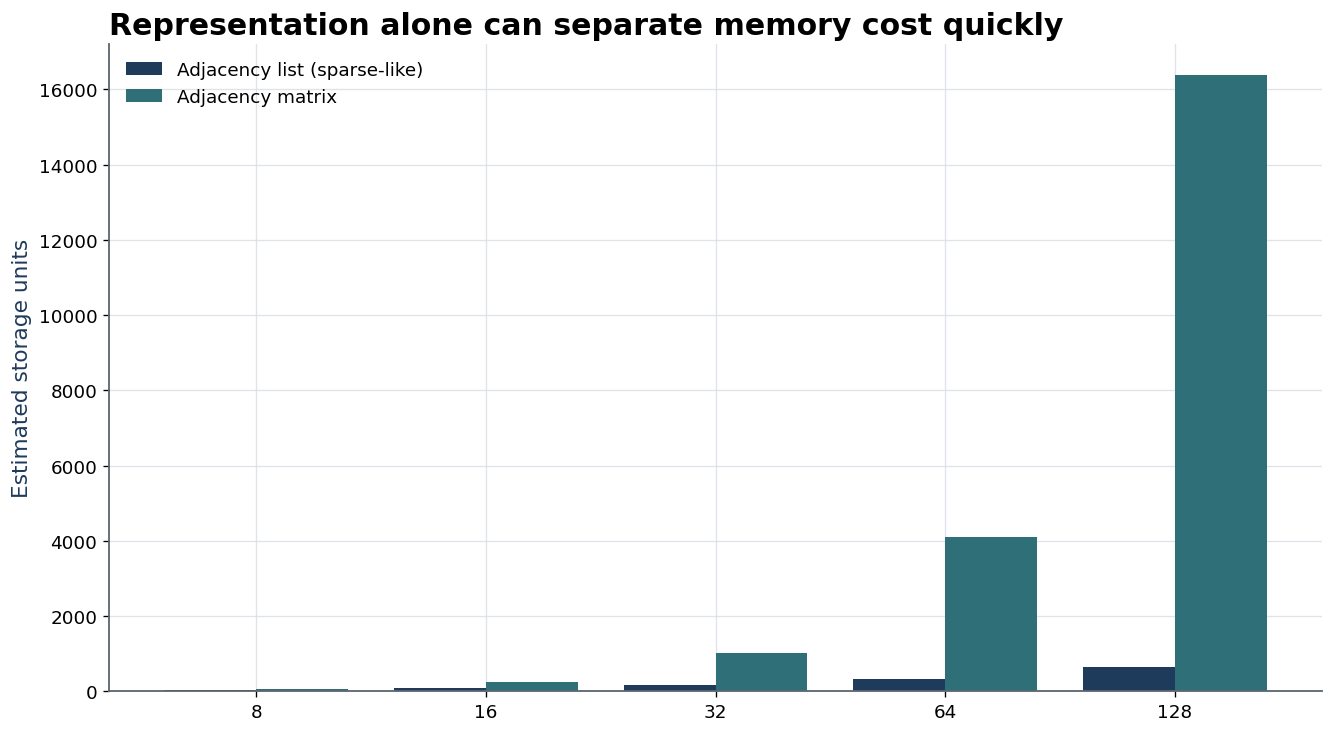

In [3]:
plot_grouped_bars(
    [str(n) for n in representation_growth_df['n']],
    {
        'Adjacency list (sparse-like)': representation_growth_df['adjacency list (sparse-like)'],
        'Adjacency matrix': representation_growth_df['adjacency matrix'],
    },
    title='Representation alone can separate memory cost quickly',
    ylabel='Estimated storage units',
)
plt.show()


Even before we choose an algorithm, the representation already changes what we must store. A matrix grows with every possible pair of vertices; a list grows mostly with the edges that actually exist.


In [4]:
formula_df = pd.DataFrame(
    {
        'Representation': ['Adjacency list', 'Adjacency matrix'],
        'Idea': [
            'Store only the neighbors that really exist',
            'Reserve a slot for every possible pair of vertices',
        ],
        'Memory proxy': ['V + 2E (undirected)', 'V^2'],
        'Best fit': ['Sparse graphs', 'Dense graphs or constant-time edge lookup'],
    }
)
display_wrapped(formula_df)


,Representation,Idea,Memory proxy,Best fit
0,Adjacency list,Store only the neighbors that really exist,V + 2E (undirected),Sparse graphs
1,Adjacency matrix,Reserve a slot for every possible pair of vertices,V^2,Dense graphs or constant-time edge lookup


In [5]:
display_wrapped(representation_growth_df)


,n,adjacency list (sparse-like),adjacency matrix,matrix / list ratio
0,8,40,64,1.600
1,16,80,256,3.200
2,32,160,1024,6.400
3,64,320,4096,12.800
4,128,640,16384,25.600


In [6]:
display_wrapped(Markdown(markdown_box(
    'Graph complexity starts before traversal. The same abstract graph can demand very different memory depending on how we encode it.'
)))


> **Takeaway:**
> Graph complexity starts before traversal. The same abstract graph can demand very different memory depending on how we encode it.

In [7]:
display_wrapped(Markdown(instructor_prompt(
    'If the graph is mostly empty, would you rather pay for all possible edges or only for the edges that actually exist?'
)))


> **Instructor Prompt:**
> If the graph is mostly empty, would you rather pay for all possible edges or only for the edges that actually exist?

## 2. Two ways to store the same graph

**Concept question:** What changes when one graph is viewed as a neighbor list versus a table of possible connections?


To keep the comparison honest, we reuse one small graph and watch it through several views. The mathematical object stays fixed while the representation changes around it.

In [8]:
example_adj_list = {
    'A': ['B', 'C'],
    'B': ['A', 'D', 'E'],
    'C': ['A', 'F', 'G'],
    'D': ['B'],
    'E': ['B', 'F'],
    'F': ['C', 'E', 'G'],
    'G': ['C', 'F'],
}
example_positions = {
    'A': (0.0, 1.8),
    'B': (-1.2, 0.9),
    'C': (1.2, 0.9),
    'D': (-1.7, -0.1),
    'E': (-0.5, -0.1),
    'F': (0.7, -0.1),
    'G': (1.9, -0.1),
}
example_node_order = ['A', 'B', 'C', 'D', 'E', 'F', 'G']
example_matrix, _ = adjacency_matrix_from_list(example_adj_list, node_order=example_node_order)

example_num_vertices = len(example_node_order)
example_num_edges = int(np.count_nonzero(example_matrix) // 2)


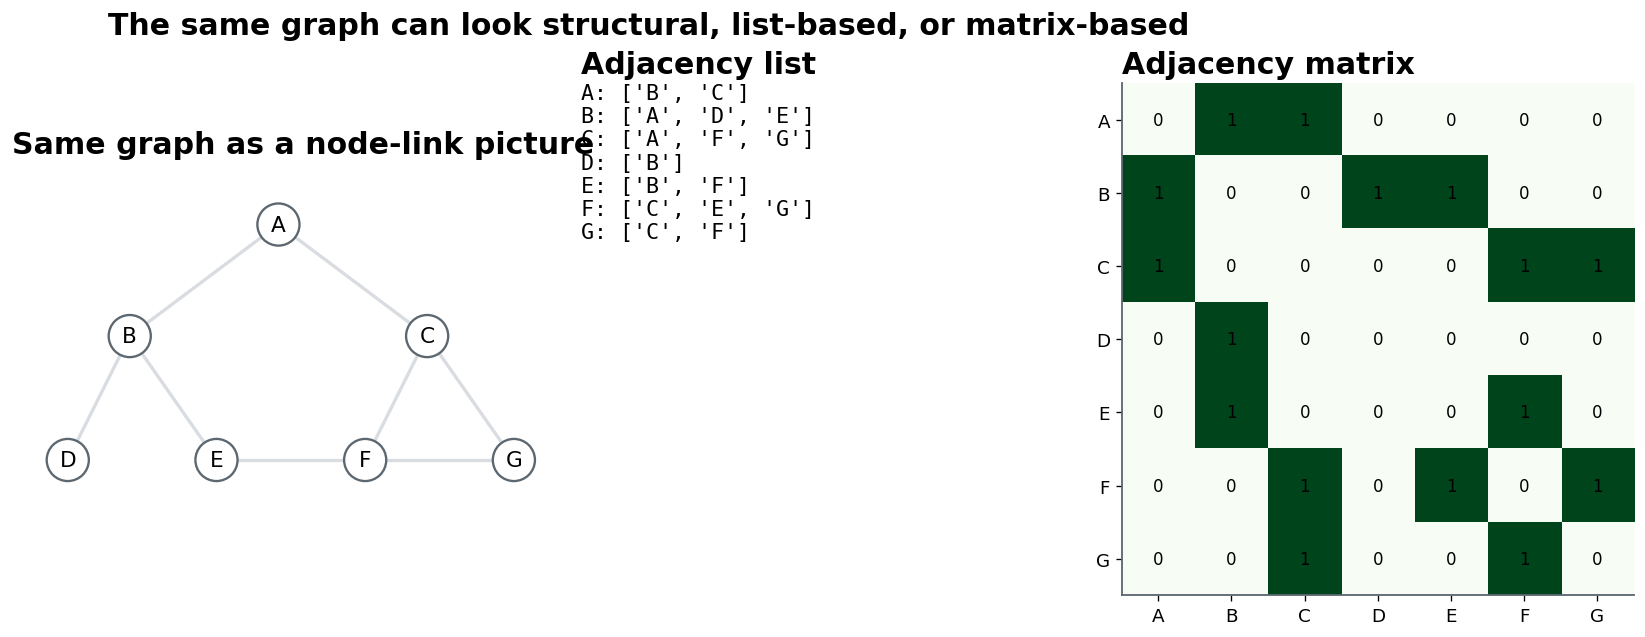

In [9]:
plot_representation_views(
    example_adj_list,
    example_positions,
    node_order=example_node_order,
    title='The same graph can look structural, list-based, or matrix-based',
)
plt.show()


The graph itself did not change. Only the representation changed. That is the key lesson: complexity statements depend on what operations the representation makes cheap or expensive.


In [10]:
example_representation_df = pd.DataFrame(
    {
        'Metric': [
            'Vertices V',
            'Undirected edges E',
            'Adjacency-list storage proxy',
            'Adjacency-matrix storage proxy',
            'Matrix occupancy',
        ],
        'Value': [
            example_num_vertices,
            example_num_edges,
            adjacency_list_storage_units(example_num_vertices, example_num_edges),
            adjacency_matrix_storage_units(example_num_vertices),
            f'{np.count_nonzero(example_matrix) / example_matrix.size:.1%}',
        ],
    }
)
display_wrapped(example_representation_df)


,Metric,Value
0,Vertices V,7
1,Undirected edges E,8
2,Adjacency-list storage proxy,23
3,Adjacency-matrix storage proxy,49
4,Matrix occupancy,32.7%


In [11]:
example_usage_df = pd.DataFrame(
    {
        'Question': [
            'Which vertices touch B?',
            'Is E connected to F?',
            'How many empty edge slots are reserved?',
        ],
        'Adjacency list view': [
            "Read neighbors of B directly: ['A', 'D', 'E']",
            "Search within E's neighbor list",
            'No explicit storage for absent edges',
        ],
        'Adjacency matrix view': [
            'Scan row B across all vertices',
            'Read one matrix cell immediately',
            f'{example_matrix.size - np.count_nonzero(example_matrix)} empty cells still exist',
        ],
    }
)
display_wrapped(example_usage_df)


,Question,Adjacency list view,Adjacency matrix view
0,Which vertices touch B?,"Read neighbors of B directly: ['A', 'D', 'E']",Scan row B across all vertices
1,Is E connected to F?,Search within E's neighbor list,Read one matrix cell immediately
2,How many empty edge slots are reserved?,No explicit storage for absent edges,33 empty cells still exist


In [12]:
display_wrapped(Markdown(markdown_box(
    'Adjacency lists and adjacency matrices answer different questions cheaply. Representation changes what “easy” means.'
)))


> **Takeaway:**
> Adjacency lists and adjacency matrices answer different questions cheaply. Representation changes what “easy” means.

In [13]:
display_wrapped(Markdown(instructor_prompt(
    'If you needed to test many possible edges quickly, which representation would feel more natural?'
)))


> **Instructor Prompt:**
> If you needed to test many possible edges quickly, which representation would feel more natural?

## 3. Sparse vs dense graphs

**Concept question:** When does a matrix feel wasteful, and when does that waste start to disappear?


Sparsity is where representation cost becomes visually obvious. Two graphs can have the same vertex count but very different edge structure, and that difference changes both memory use and traversal behavior.

In [14]:
def connected_random_graph_matrix(num_vertices, extra_edge_probability, rng):
    """Build a connected undirected graph by starting with a chain and adding random edges."""
    matrix = np.zeros((num_vertices, num_vertices), dtype=int)
    for index in range(num_vertices - 1):
        matrix[index, index + 1] = 1
        matrix[index + 1, index] = 1

    random_upper = rng.random((num_vertices, num_vertices))
    for i in range(num_vertices):
        for j in range(i + 2, num_vertices):
            if random_upper[i, j] < extra_edge_probability:
                matrix[i, j] = 1
                matrix[j, i] = 1
    return matrix


def matrix_to_adj_list(matrix, labels=None):
    """Convert an undirected adjacency matrix into a sorted adjacency list."""
    if labels is None:
        labels = list(range(matrix.shape[0]))
    adj_list = {}
    for i, label in enumerate(labels):
        neighbors = [labels[j] for j in range(matrix.shape[1]) if matrix[i, j] == 1]
        adj_list[label] = neighbors
    return adj_list


sparse_n = 18
sparse_matrix = connected_random_graph_matrix(sparse_n, extra_edge_probability=0.03, rng=rng)
dense_matrix = connected_random_graph_matrix(sparse_n, extra_edge_probability=0.45, rng=rng)

sparse_adj_list = matrix_to_adj_list(sparse_matrix)
dense_adj_list = matrix_to_adj_list(dense_matrix)

sparse_edges = int(np.count_nonzero(np.triu(sparse_matrix, 1)))
dense_edges = int(np.count_nonzero(np.triu(dense_matrix, 1)))


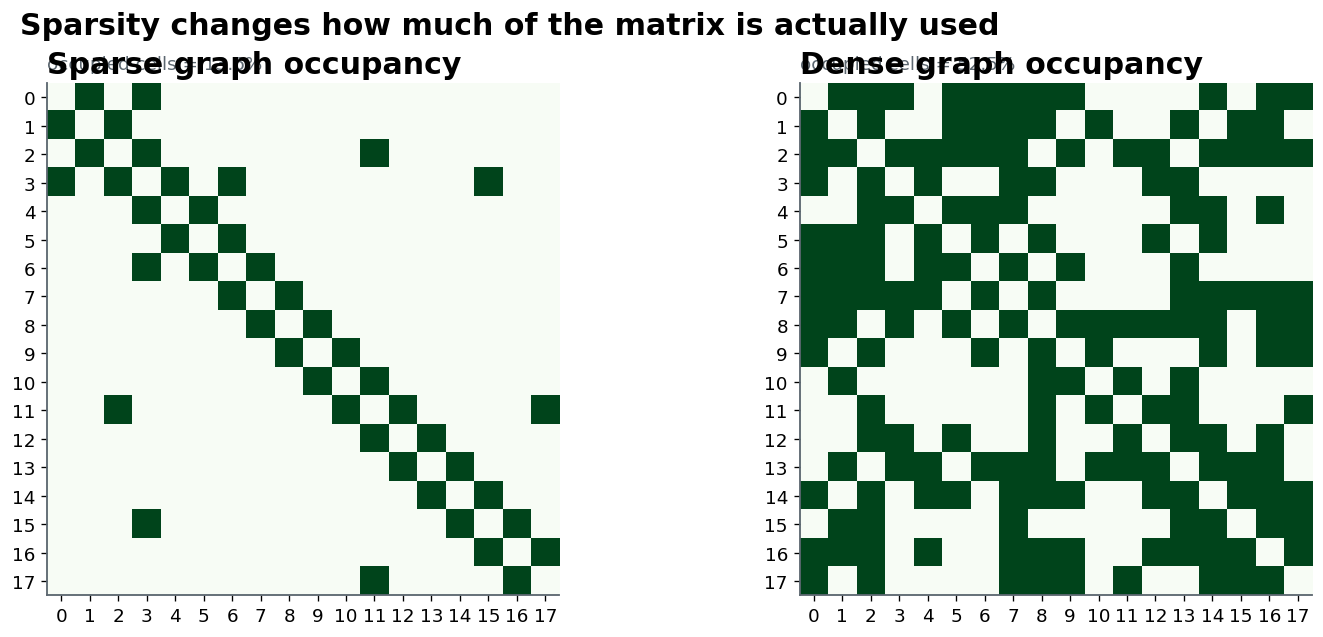

In [15]:
plot_sparsity_heatmaps(
    sparse_matrix,
    dense_matrix,
    sparse_title='Sparse graph occupancy',
    dense_title='Dense graph occupancy',
    title='Sparsity changes how much of the matrix is actually used',
)
plt.show()


In the sparse case, most matrix cells are empty. In the dense case, many more potential edges are actually present, so the matrix begins to look less wasteful.


In [16]:
sparsity_df = pd.DataFrame(
    {
        'Graph': ['Sparse example', 'Dense example'],
        'Vertices V': [sparse_n, sparse_n],
        'Undirected edges E': [sparse_edges, dense_edges],
        'Density E / (V(V-1)/2)': [
            sparse_edges / (sparse_n * (sparse_n - 1) / 2),
            dense_edges / (sparse_n * (sparse_n - 1) / 2),
        ],
        'Adjacency-list storage proxy': [
            adjacency_list_storage_units(sparse_n, sparse_edges),
            adjacency_list_storage_units(sparse_n, dense_edges),
        ],
        'Adjacency-matrix storage proxy': [
            adjacency_matrix_storage_units(sparse_n),
            adjacency_matrix_storage_units(sparse_n),
        ],
    }
)
display_wrapped(sparsity_df)


,Graph,Vertices V,Undirected edges E,Density E / (V(V-1)/2),Adjacency-list storage proxy,Adjacency-matrix storage proxy
0,Sparse example,18,22,0.144,62,324
1,Dense example,18,85,0.556,188,324


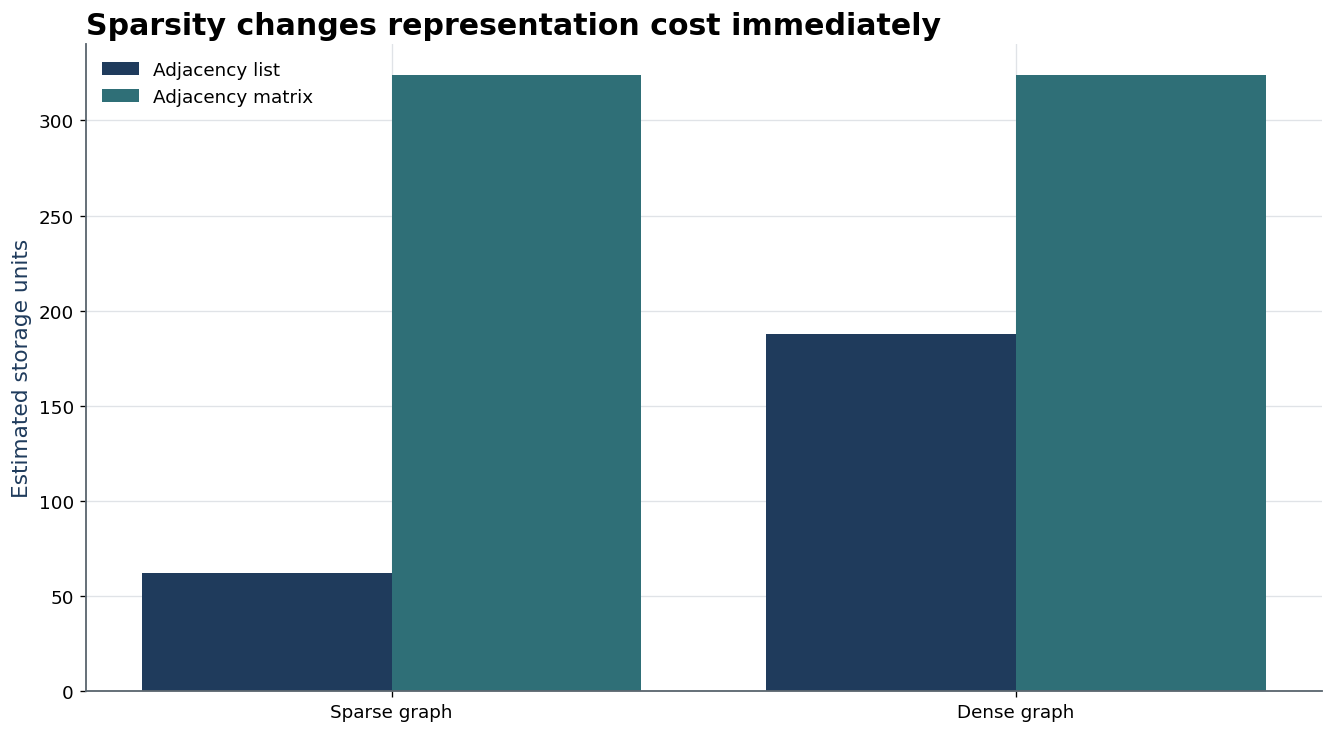

In [17]:
plot_grouped_bars(
    ['Sparse graph', 'Dense graph'],
    {
        'Adjacency list': [
            adjacency_list_storage_units(sparse_n, sparse_edges),
            adjacency_list_storage_units(sparse_n, dense_edges),
        ],
        'Adjacency matrix': [
            adjacency_matrix_storage_units(sparse_n),
            adjacency_matrix_storage_units(sparse_n),
        ],
    },
    title='Sparsity changes representation cost immediately',
    ylabel='Estimated storage units',
)
plt.show()


In [18]:
display_wrapped(Markdown(markdown_box(
    'The word sparse is not cosmetic. It tells us whether storing all possible edges is reasonable or wasteful.'
)))


> **Takeaway:**
> The word sparse is not cosmetic. It tells us whether storing all possible edges is reasonable or wasteful.

In [19]:
display_wrapped(Markdown(instructor_prompt(
    'If two graphs have the same number of vertices but very different densities, should you expect the same representation to be best for both?'
)))


> **Instructor Prompt:**
> If two graphs have the same number of vertices but very different densities, should you expect the same representation to be best for both?

## 4. Traversal intuition with BFS and DFS

**Concept question:** When we traverse a graph, do we pay for actual edges only, or for the representation we must inspect on the way?


Traversal is where algorithm and representation meet. BFS and DFS explore the same graph with different priorities, and the representation decides how cheaply each next-neighbor question can be answered.

In [20]:
def bfs_adj_list(adj_list, start):
    """Breadth-first search on an adjacency list with edge-check counting."""
    queue = [start]
    visited = {start}
    parent = {start: None}
    order = []
    edge_checks = 0

    while queue:
        current = queue.pop(0)
        order.append(current)
        for neighbor in adj_list[current]:
            edge_checks += 1
            if neighbor not in visited:
                visited.add(neighbor)
                parent[neighbor] = current
                queue.append(neighbor)
    return order, parent, edge_checks


def bfs_adj_matrix(matrix, labels, start_index=0):
    """Breadth-first search by scanning every cell in the current row."""
    queue = [start_index]
    visited = {start_index}
    parent_index = {start_index: None}
    order_index = []
    cell_checks = 0

    while queue:
        current = queue.pop(0)
        order_index.append(current)
        for candidate in range(matrix.shape[1]):
            cell_checks += 1
            if matrix[current, candidate] == 1 and candidate not in visited:
                visited.add(candidate)
                parent_index[candidate] = current
                queue.append(candidate)

    order = [labels[index] for index in order_index]
    parent = {
        labels[index]: (None if predecessor is None else labels[predecessor])
        for index, predecessor in parent_index.items()
    }
    return order, parent, cell_checks


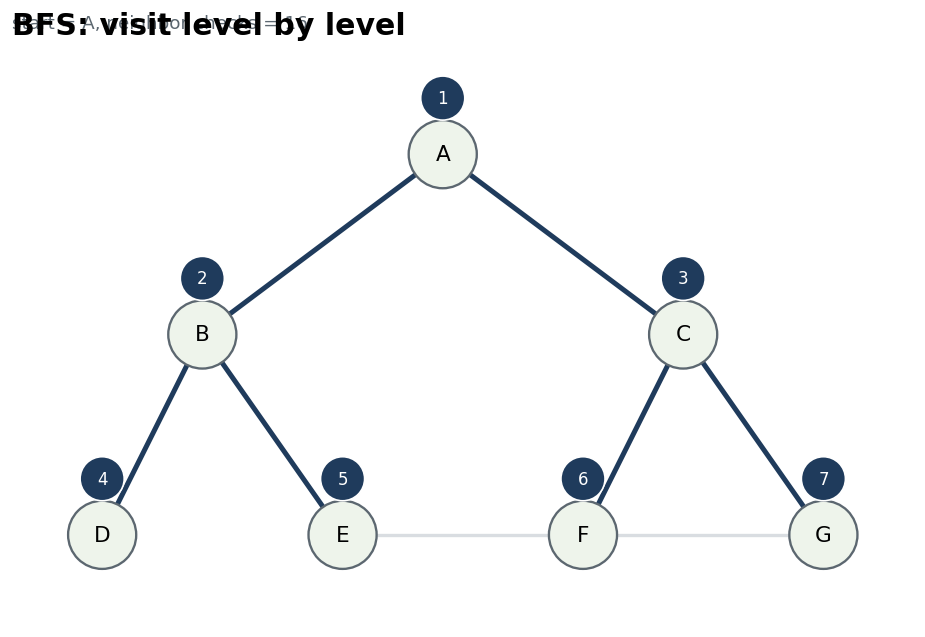

In [21]:
bfs_order, bfs_parent, bfs_checks = bfs_adj_list(example_adj_list, 'A')
plot_traversal_graph(
    example_adj_list,
    example_positions,
    bfs_order,
    bfs_parent,
    title='BFS: visit level by level',
    subtitle=f'start = A, neighbor checks = {bfs_checks}',
)
plt.show()


In [22]:
def dfs_adj_list(adj_list, start):
    """Depth-first search on an adjacency list with edge-check counting."""
    stack = [start]
    visited = set()
    parent = {start: None}
    order = []
    edge_checks = 0

    while stack:
        current = stack.pop()
        if current in visited:
            continue
        visited.add(current)
        order.append(current)

        for neighbor in reversed(adj_list[current]):
            edge_checks += 1
            if neighbor not in visited:
                if neighbor not in parent:
                    parent[neighbor] = current
                stack.append(neighbor)
    return order, parent, edge_checks


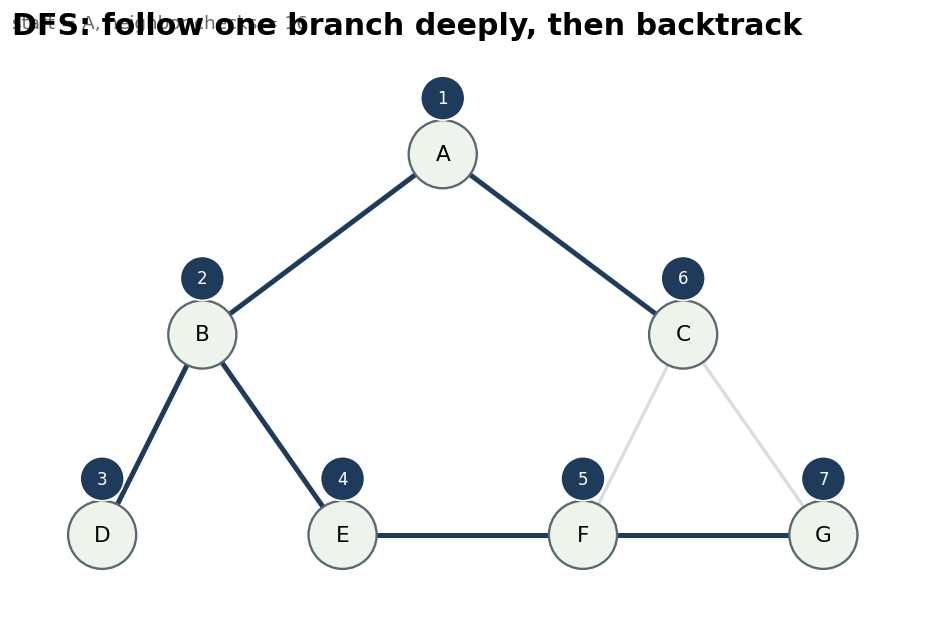

In [23]:
dfs_order, dfs_parent, dfs_checks = dfs_adj_list(example_adj_list, 'A')
plot_traversal_graph(
    example_adj_list,
    example_positions,
    dfs_order,
    dfs_parent,
    title='DFS: follow one branch deeply, then backtrack',
    subtitle=f'start = A, neighbor checks = {dfs_checks}',
)
plt.show()


BFS and DFS solve different traversal tasks, but they share a key structural lesson: in an adjacency list, they touch each vertex and each stored edge a limited number of times. That is the intuition behind `O(V + E)`.


In [24]:
traversal_theory_df = pd.DataFrame(
    {
        'Representation': ['Adjacency list', 'Adjacency matrix'],
        'Traversal idea': [
            'Look only at neighbors that are actually stored',
            'Scan an entire row to discover neighbors',
        ],
        'BFS/DFS cost intuition': ['O(V + E)', 'O(V^2) when every row is scanned'],
        'Why': [
            'Work grows with vertices plus existing edges',
            'Work grows with all possible vertex pairs examined by row scans',
        ],
    }
)
display_wrapped(traversal_theory_df)


,Representation,Traversal idea,BFS/DFS cost intuition,Why
0,Adjacency list,Look only at neighbors that are actually stored,O(V + E),Work grows with vertices plus existing edges
1,Adjacency matrix,Scan an entire row to discover neighbors,O(V^2) when every row is scanned,Work grows with all possible vertex pairs examined by row scans


,Scenario,BFS on adjacency list,BFS on adjacency matrix
0,Sparse graph,44,324
1,Dense graph,170,324


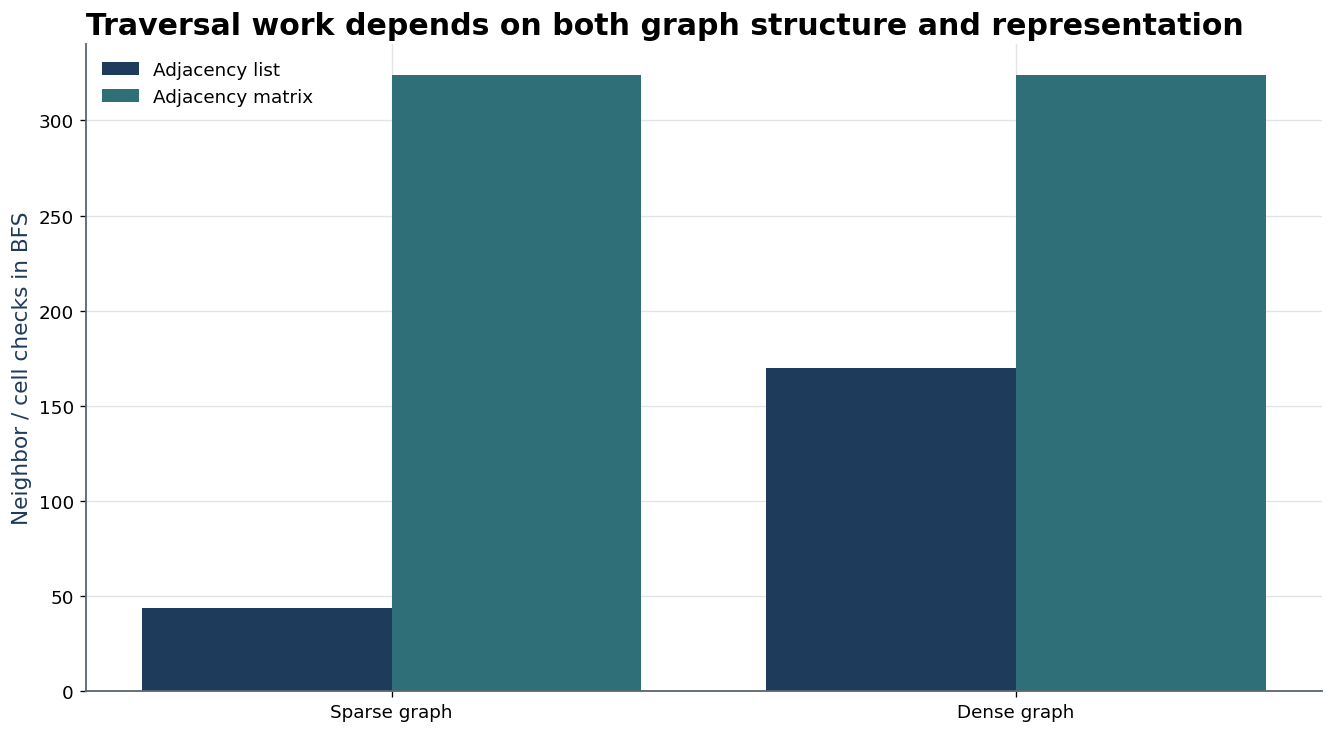

In [25]:
sparse_bfs_list_order, sparse_bfs_list_parent, sparse_bfs_list_checks = bfs_adj_list(sparse_adj_list, 0)
sparse_bfs_matrix_order, sparse_bfs_matrix_parent, sparse_bfs_matrix_checks = bfs_adj_matrix(sparse_matrix, list(range(sparse_n)), 0)
dense_bfs_list_order, dense_bfs_list_parent, dense_bfs_list_checks = bfs_adj_list(dense_adj_list, 0)
dense_bfs_matrix_order, dense_bfs_matrix_parent, dense_bfs_matrix_checks = bfs_adj_matrix(dense_matrix, list(range(sparse_n)), 0)

bfs_measurement_df = pd.DataFrame(
    {
        'Scenario': ['Sparse graph', 'Dense graph'],
        'BFS on adjacency list': [sparse_bfs_list_checks, dense_bfs_list_checks],
        'BFS on adjacency matrix': [sparse_bfs_matrix_checks, dense_bfs_matrix_checks],
    }
)
display_wrapped(bfs_measurement_df)

plot_grouped_bars(
    bfs_measurement_df['Scenario'].tolist(),
    {
        'Adjacency list': bfs_measurement_df['BFS on adjacency list'].tolist(),
        'Adjacency matrix': bfs_measurement_df['BFS on adjacency matrix'].tolist(),
    },
    title='Traversal work depends on both graph structure and representation',
    ylabel='Neighbor / cell checks in BFS',
)
plt.show()


In [26]:
display_wrapped(Markdown(markdown_box(
    'Traversal complexity is not only about the algorithm name. The same BFS idea can feel linear on an adjacency list and much heavier on an adjacency matrix.'
)))


> **Takeaway:**
> Traversal complexity is not only about the algorithm name. The same BFS idea can feel linear on an adjacency list and much heavier on an adjacency matrix.

In [27]:
display_wrapped(Markdown(instructor_prompt(
    'If the graph is sparse, why does scanning every matrix row feel like paying for edges that are not really there?'
)))


> **Instructor Prompt:**
> If the graph is sparse, why does scanning every matrix row feel like paying for edges that are not really there?

## 5. What costs dominate?

**Concept question:** If you had to choose a representation for a real task, would time, memory, and graph density always point to the same answer?


This section synthesizes the earlier pieces into a multi-dimensional cost picture. The goal is not to pick one universal winner, but to make clear which cost dominates in which setting.

In [28]:
summary_df = pd.DataFrame(
    {
        'scenario': [
            'Sparse + list',
            'Sparse + matrix',
            'Dense + list',
            'Dense + matrix',
        ],
        'memory_units': [
            adjacency_list_storage_units(sparse_n, sparse_edges),
            adjacency_matrix_storage_units(sparse_n),
            adjacency_list_storage_units(sparse_n, dense_edges),
            adjacency_matrix_storage_units(sparse_n),
        ],
        'edge_checks': [
            sparse_bfs_list_checks,
            sparse_bfs_matrix_checks,
            dense_bfs_list_checks,
            dense_bfs_matrix_checks,
        ],
        'representation': ['list', 'matrix', 'list', 'matrix'],
        'density': ['sparse', 'sparse', 'dense', 'dense'],
    }
)


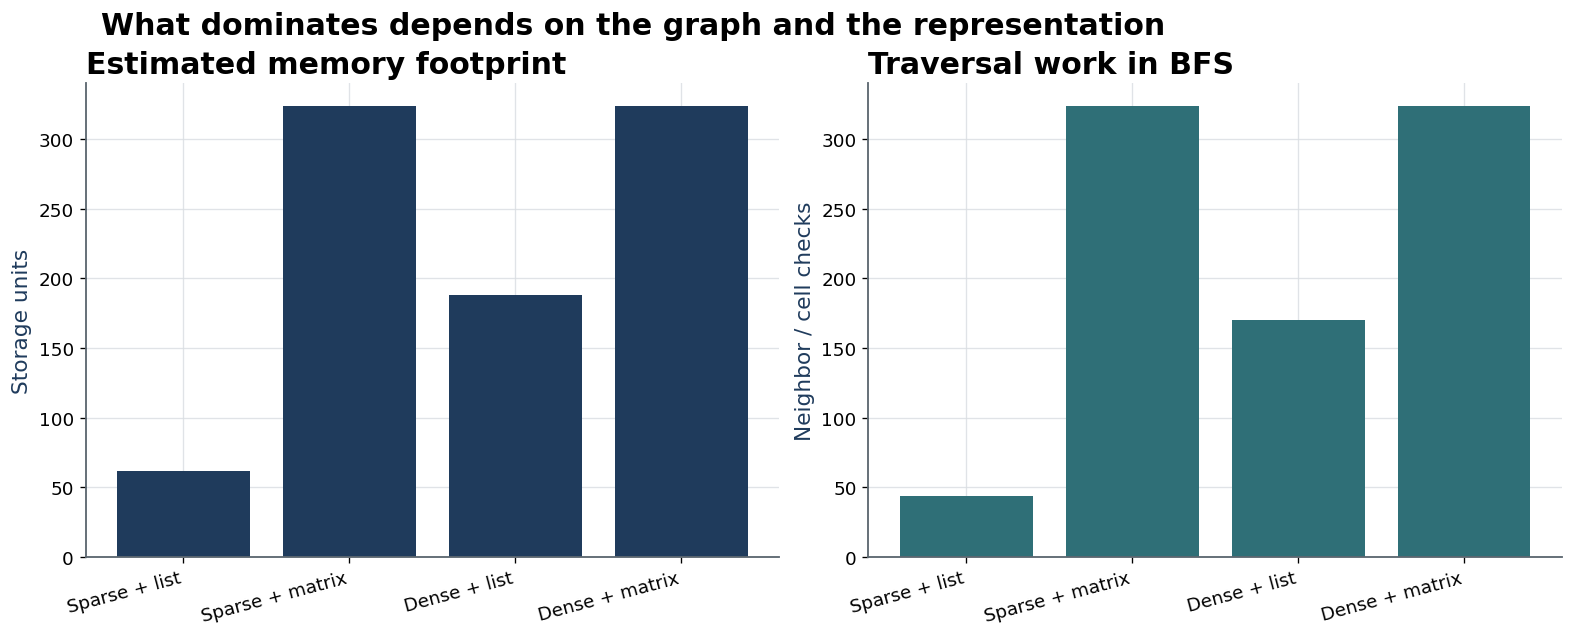

In [29]:
plot_cost_tradeoff_summary(
    summary_df,
    title='What dominates depends on the graph and the representation',
)
plt.show()


There is no universal winner. On sparse graphs, adjacency lists often dominate on memory and traversal work. On dense graphs, matrices become more defensible, especially when fast edge lookup matters.


In [30]:
asymptotic_summary_df = pd.DataFrame(
    {
        'Scenario': ['Sparse + adjacency list', 'Sparse + adjacency matrix', 'Dense + adjacency list', 'Dense + adjacency matrix'],
        'Memory intuition': ['Close to O(V)', 'Always O(V^2)', 'Approaches O(V^2)', 'O(V^2)'],
        'Traversal intuition': ['O(V + E)', 'O(V^2)', 'O(V + E) with large E', 'O(V^2)'],
        'Best use case': [
            'Large sparse graphs and traversals',
            'Fast edge tests on small/moderate graphs',
            'Dense data where many edges really exist',
            'Dense graphs or matrix-based algebraic workflows',
        ],
    }
)
display_wrapped(asymptotic_summary_df)


,Scenario,Memory intuition,Traversal intuition,Best use case
0,Sparse + adjacency list,Close to O(V),O(V + E),Large sparse graphs and traversals
1,Sparse + adjacency matrix,Always O(V^2),O(V^2),Fast edge tests on small/moderate graphs
2,Dense + adjacency list,Approaches O(V^2),O(V + E) with large E,Dense data where many edges really exist
3,Dense + adjacency matrix,O(V^2),O(V^2),Dense graphs or matrix-based algebraic workflows


In [31]:
display_wrapped(summary_df)


,scenario,memory_units,edge_checks,representation,density
0,Sparse + list,62,44,list,sparse
1,Sparse + matrix,324,324,matrix,sparse
2,Dense + list,188,170,list,dense
3,Dense + matrix,324,324,matrix,dense


In [32]:
display_wrapped(Markdown(markdown_box(
    'Complexity is multi-dimensional. Time, memory, and representation all matter, and the dominant cost can change with sparsity and task.'
)))


> **Takeaway:**
> Complexity is multi-dimensional. Time, memory, and representation all matter, and the dominant cost can change with sparsity and task.

In [33]:
display_wrapped(Markdown(instructor_prompt(
    'If you had to traverse the graph many times but almost never test arbitrary edges, which representation would you choose and why?'
)))


> **Instructor Prompt:**
> If you had to traverse the graph many times but almost never test arbitrary edges, which representation would you choose and why?

## 6. Recap / takeaways


In [34]:
display_wrapped(Markdown(markdown_box(
    """
    1. A graph is both a mathematical object and a stored data structure.
    2. The same graph can be encoded as an adjacency list or an adjacency matrix.
    3. Representation cost depends strongly on sparsity and density.
    4. BFS and DFS are naturally explained as O(V + E) on adjacency lists.
    5. Complexity is not only about runtime; memory and representation are part of the story.
    """,
    title='Recap',
)))


> **Recap:**
> 1. A graph is both a mathematical object and a stored data structure.
> 2. The same graph can be encoded as an adjacency list or an adjacency matrix.
> 3. Representation cost depends strongly on sparsity and density.
> 4. BFS and DFS are naturally explained as O(V + E) on adjacency lists.
> 5. Complexity is not only about runtime; memory and representation are part of the story.

## 7. Questions for students

- Why can an adjacency matrix feel wasteful on a sparse graph even before traversal begins?
- When does an adjacency matrix become more reasonable than an adjacency list?
- Why do BFS and DFS feel like `O(V + E)` on an adjacency list?
- What does `O(V^2)` mean intuitively when traversal is done from an adjacency matrix?
- If two graphs have the same number of vertices but different densities, should you expect the same dominant cost?
